In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
import pandas as pd
import os

# 1. GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

# 2. 데이터 로드 함수
def load_data():
    # 환자 데이터
    with open('../data/processed_data.pkl', 'rb') as f:
        data = pickle.load(f)
    
    # 그래프 데이터
    with open('../data/graph_data.pkl', 'rb') as f:
        graph = pickle.load(f)
        
    return data['patient_history'], data['vocabs'], graph

patient_history, vocabs, graph_data = load_data()

# 3. 그래프 데이터를 PyTorch Sparse Tensor로 변환 (GNN 연산용)
# GNN은 행렬 곱셈(AXW)을 해야 하는데, A가 너무 크고 비어있으니 Sparse로 다룹니다.
num_nodes = graph_data['num_nodes']
edge_index = graph_data['edge_index'].to(device)
edge_weight = graph_data['edge_weight'].to(device)

# Sparse Adjacency Matrix 생성
adj_sparse = torch.sparse_coo_tensor(
    edge_index, 
    edge_weight, 
    (num_nodes, num_nodes)
).to(device)

print(f"✅ 데이터 로드 완료")
print(f"- 그래프 노드 수: {num_nodes}")
print(f"- 그래프 엣지 수: {edge_index.shape[1]}")

사용 장치: cpu
✅ 데이터 로드 완료
- 그래프 노드 수: 2455
- 그래프 엣지 수: 4311


In [2]:
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super(GraphConvolution, self).__init__()
        # 가중치 행렬 W
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        # 편향 b
        self.bias = nn.Parameter(torch.FloatTensor(out_features))
        self.reset_parameters()

    def reset_parameters(self):
        # 가중치 초기화 (Xavier Initialization)
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x, adj):
        # 1. 선형 변환 (H * W)
        support = torch.mm(x, self.weight)
        
        # 2. 이웃 정보 집계 (A * Support)
        # Sparse Matrix Multiplication 사용
        output = torch.sparse.mm(adj, support)
        
        return output + self.bias

print("✅ Custom GCN 레이어 정의 완료!")

✅ Custom GCN 레이어 정의 완료!


In [3]:
class GNN_GRU(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, hidden_dim=64, output_dim=1):
        super(GNN_GRU, self).__init__()
        
        # 1. 기본 임베딩 (Lookup Table)
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        
        # 2. GCN 레이어 (지식 그래프로 임베딩 강화)
        self.gcn = GraphConvolution(embedding_dim, embedding_dim)
        
        # 3. 시계열 처리 (GRU)
        # 입력 크기: 임베딩 차원 * 3 (진단+시술+약물 Concatenation 할 것이므로)
        self.gru = nn.GRU(embedding_dim * 3, hidden_dim, batch_first=True)
        
        # 4. 최종 예측
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, diag_idx, proc_idx, med_idx, adj):
        """
        diag_idx: (Batch, Time, Max_Codes) 형태는 아님. Multi-hot을 쓰기 때문에
                  입력 방식이 조금 달라야 합니다.
                  하지만 여기선 '임베딩 테이블' 자체를 GNN으로 업데이트 한 뒤,
                  Multi-hot 벡터와 곱해서 환자 표현을 만듭니다.
        """
        # [Step 1] 전체 의료 코드 임베딩 업데이트 (Node Embedding Update)
        # 모든 노드(코드)의 기본 임베딩을 가져옴
        all_nodes_idx = torch.arange(self.embedding.num_embeddings, device=device)
        x = self.embedding(all_nodes_idx)
        
        # 지식 그래프(adj)를 통과시켜 임베딩 진화! (H -> H')
        x_graph = F.relu(self.gcn(x, adj))
        
        # [Step 2] 환자 방문 기록 생성 (Visit Representation)
        # 입력으로 들어온 Multi-hot 벡터(Batch, Time, Vocab)와 
        # 업데이트된 임베딩(Vocab, Dim)을 곱함 -> (Batch, Time, Dim)
        # 이를 위해선 matmul을 사용합니다.
        
        # 진단, 시술, 약물 각각 처리
        # diag (B, T, V_d) x Embed (V, D) -> 부분적으로 매칭 필요
        # 편의상 입력인 diag, proc, med가 이미 Multi-hot Tensor라고 가정하고 진행
        
        # 전체 임베딩을 구역별로 자름 (진단/시술/약물)
        # (간단한 구현을 위해 전체 임베딩 행렬을 그대로 씁니다)
        
        embed_diag = torch.matmul(diag_idx, x_graph[:diag_idx.shape[-1]])
        embed_proc = torch.matmul(proc_idx, x_graph[diag_idx.shape[-1]:diag_idx.shape[-1]+proc_idx.shape[-1]]) 
        # 위 인덱싱은 복잡하니, 더 쉬운 방법: 전체 x_graph를 사용
        
        # 임베딩 차원이 맞아야 하므로, 아래 방식 사용:
        # 입력(diag, proc, med)은 Multi-hot Vector (B, T, V)
        # x_graph는 (Total_V, D)
        
        # 진단 부분 임베딩
        num_d = diag_idx.size(-1)
        num_p = proc_idx.size(-1)
        
        emb_d = torch.matmul(diag_idx, x_graph[:num_d])
        emb_p = torch.matmul(proc_idx, x_graph[num_d:num_d+num_p])
        emb_m = torch.matmul(med_idx, x_graph[num_d+num_p:])
        
        # [Step 3] 시퀀스 결합 및 GRU 통과
        # (Batch, Time, Dim*3)
        visit_rep = torch.cat([emb_d, emb_p, emb_m], dim=-1)
        
        _, h_n = self.gru(visit_rep)
        last_hidden = h_n.squeeze(0)
        
        return self.fc(self.dropout(last_hidden))

print("✅ GNN_GRU 모델 설계 완료!")

✅ GNN_GRU 모델 설계 완료!


In [4]:
# --- [필수] Dataset & Collator 재정의 (이전 단계 복사) ---
class MIMICDataset(Dataset):
    def __init__(self, patient_history, labels, max_len=50):
        self.patient_ids = list(patient_history.keys())
        self.history = patient_history
        self.labels = labels
        self.max_len = max_len
    def __len__(self): return len(self.patient_ids)
    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        visits = self.history[pid]
        diag = [v.get('conditions', []) for v in visits][-self.max_len:]
        proc = [v.get('procedures', []) for v in visits][-self.max_len:]
        drug = [v.get('drugs', []) for v in visits][-self.max_len:]
        label = self.labels.get(pid, 0.0)
        return {'patient_id': pid, 'num_visits': len(diag), 'diagnosis': diag, 
                'procedure': proc, 'medication': drug, 'label': torch.tensor([label], dtype=torch.float32)}

def collate_fn(batch):
    max_visits = max([s['num_visits'] for s in batch])
    batch_size = len(batch)
    num_diag = len(vocabs['diag'])
    num_proc = len(vocabs['proc'])
    num_drug = len(vocabs['drug'])
    
    t_d = torch.zeros(batch_size, max_visits, num_diag)
    t_p = torch.zeros(batch_size, max_visits, num_proc)
    t_m = torch.zeros(batch_size, max_visits, num_drug)
    labels = []
    
    for i, s in enumerate(batch):
        labels.append(s['label'])
        for t in range(s['num_visits']):
            for c in s['diagnosis'][t]: 
                if c < num_diag: t_d[i,t,c] = 1
            for c in s['procedure'][t]: 
                if c < num_proc: t_p[i,t,c] = 1
            for c in s['medication'][t]: 
                if c < num_drug: t_m[i,t,c] = 1
                
    return {'diagnosis': t_d, 'procedure': t_p, 'medication': t_m, 
            'label': torch.stack(labels), 'patient_ids': [s['patient_id'] for s in batch]}

# --- 정답지 로드 및 로더 생성 ---
path_hosp = '../data/hosp/'
df_adm = pd.read_csv(path_hosp + 'admissions.csv' if os.path.exists(path_hosp + 'admissions.csv') else path_hosp + 'admissions.csv.gz')
mortality_dict = {pid: (1.0 if grp['hospital_expire_flag'].sum() > 0 else 0.0) for pid, grp in df_adm.groupby('subject_id')}

dataset = MIMICDataset(patient_history, mortality_dict)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
print("✅ 데이터로더 준비 완료")

✅ 데이터로더 준비 완료


In [5]:
# 1. 모델 생성
model = GNN_GRU(num_nodes=num_nodes, embedding_dim=32, hidden_dim=64).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. 학습 기록
train_losses = []
train_accs = []

print("=== GNN-GRU 모델 학습 시작 ===")

for epoch in range(10): # 10 Epoch
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in dataloader:
        # 데이터 이동
        diag = batch['diagnosis'].to(device)
        proc = batch['procedure'].to(device)
        med = batch['medication'].to(device)
        labels = batch['label'].to(device)
        
        # [핵심] 모델에 그래프(adj_sparse)를 같이 넣어줍니다!
        outputs = model(diag, proc, med, adj_sparse)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
    avg_loss = total_loss / len(dataloader)
    acc = 100 * correct / total
    train_losses.append(avg_loss)
    train_accs.append(acc)
    
    print(f"Epoch [{epoch+1}/10] | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

print("=== 학습 완료! ===")

# 모델 저장
torch.save(model.state_dict(), '../data/ehr_gnn_model.pth')
print("💾 GNN 모델 저장 완료")

=== GNN-GRU 모델 학습 시작 ===
Epoch [1/10] | Loss: 0.6386 | Acc: 84.00%
Epoch [2/10] | Loss: 0.5820 | Acc: 85.00%
Epoch [3/10] | Loss: 0.5198 | Acc: 85.00%
Epoch [4/10] | Loss: 0.4592 | Acc: 85.00%
Epoch [5/10] | Loss: 0.4543 | Acc: 85.00%
Epoch [6/10] | Loss: 0.4629 | Acc: 85.00%
Epoch [7/10] | Loss: 0.4372 | Acc: 85.00%
Epoch [8/10] | Loss: 0.3937 | Acc: 85.00%
Epoch [9/10] | Loss: 0.4024 | Acc: 85.00%
Epoch [10/10] | Loss: 0.4055 | Acc: 85.00%
=== 학습 완료! ===
💾 GNN 모델 저장 완료


💾 학습 결과 그래프 저장 완료: ../images/training_result_gnn.png


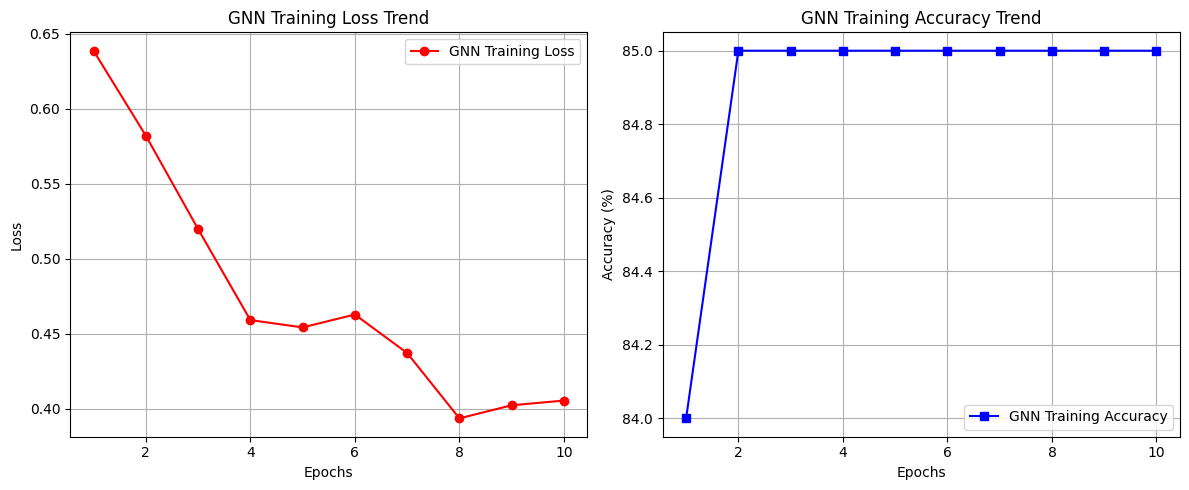

In [6]:
import matplotlib.pyplot as plt
import os

# Epoch 축 생성
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# 1. Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'r-o', label='GNN Training Loss')
plt.title('GNN Training Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, 'b-s', label='GNN Training Accuracy')
plt.title('GNN Training Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()

# 이미지 저장
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/training_result_gnn.png')
print("💾 학습 결과 그래프 저장 완료: ../images/training_result_gnn.png")

plt.show()